# Import libraries

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import tensorflow as tf
import random

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# Models
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Model selection
from sklearn.model_selection import GridSearchCV

# Neural network (Keras)
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate, Average
from tensorflow.keras.models import Model

# Statistical testing
from statsmodels.stats.contingency_tables import mcnemar

# Visualisation for XGBoost
from xgboost import plot_importance

In [16]:
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# Load dataset

In [17]:
train = pd.read_csv("/kaggle/input/human-activity-recognition/train.csv")
test  = pd.read_csv("/kaggle/input/human-activity-recognition/test.csv")

y_train = train["Activity"]
y_test  = test["Activity"]

X_train = train.drop(columns=["Activity", "subject"])
X_test  = test.drop(columns=["Activity", "subject"])


# Check activity distribution

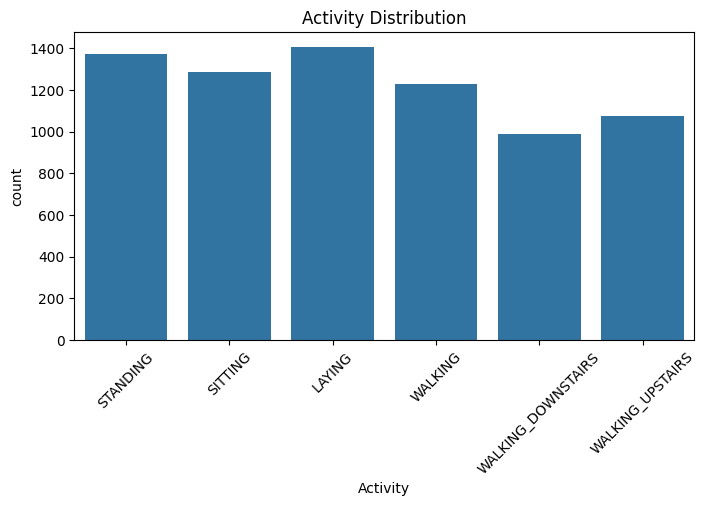

In [18]:
plt.figure(figsize=(8,4))
sns.countplot(x=train["Activity"])
plt.xticks(rotation=45)
plt.title("Activity Distribution")
plt.show()


# Separate labels and features

In [19]:
y_train = train["Activity"]
y_test  = test["Activity"]

X_train = train.drop(columns=["Activity", "subject"])
X_test  = test.drop(columns=["Activity", "subject"])

print(X_train.shape)


(7352, 561)


# Split modalities

In [20]:
acc_cols = [c for c in X_train.columns if "Acc" in c]
gyro_cols = [c for c in X_train.columns if "Gyro" in c]

X_acc_train = X_train[acc_cols].values
X_gyro_train = X_train[gyro_cols].values

X_acc_test = X_test[acc_cols].values
X_gyro_test = X_test[gyro_cols].values

print("Accel shape:", X_acc_train.shape)
print("Gyro shape:", X_gyro_train.shape)


Accel shape: (7352, 345)
Gyro shape: (7352, 213)


# Encode activity labels

In [21]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

n_classes = len(le.classes_)

In [22]:
print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])
print("Total features:", X_train.shape[1])
print("Number of activities:", n_classes)
print("Activities:", list(le.classes_))

Training samples: 7352
Test samples: 2947
Total features: 561
Number of activities: 6
Activities: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


# Scale each modality separately

In [23]:
scaler_acc = StandardScaler()
scaler_gyro = StandardScaler()

X_acc_train = scaler_acc.fit_transform(X_acc_train)
X_acc_test  = scaler_acc.transform(X_acc_test)

X_gyro_train = scaler_gyro.fit_transform(X_gyro_train)
X_gyro_test  = scaler_gyro.transform(X_gyro_test)


# single-modality model function

In [24]:
def build_single_model(input_dim, n_classes):
    inp = Input(shape=(input_dim,))
    x = Dense(128, activation="relu")(inp)
    x = Dropout(0.3)(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)
    out = Dense(n_classes, activation="softmax")(x)
    
    model = Model(inp, out)
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


# Train accelerometer model

In [25]:
start = time.time()

In [26]:
acc_model = build_single_model(X_acc_train.shape[1], n_classes)
hist_acc = acc_model.fit(
    X_acc_train,
    y_train_enc,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    verbose=1
)

print("Final Training Accuracy:", hist_acc.history['accuracy'][-1])
print("Final Validation Accuracy:", hist_acc.history['val_accuracy'][-1])

y_pred_acc = np.argmax(acc_model.predict(X_acc_test), axis=1)
print("Accelerometer Model Accuracy:", accuracy_score(y_test_enc, y_pred_acc))

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5739 - loss: 1.0958 - val_accuracy: 0.8994 - val_loss: 0.2679
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8520 - loss: 0.3464 - val_accuracy: 0.9096 - val_loss: 0.2250
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8924 - loss: 0.2570 - val_accuracy: 0.9075 - val_loss: 0.2249
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9209 - loss: 0.1953 - val_accuracy: 0.9225 - val_loss: 0.2065
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9341 - loss: 0.1728 - val_accuracy: 0.9273 - val_loss: 0.2091
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9377 - loss: 0.1589 - val_accuracy: 0.9211 - val_loss: 0.2123
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9392 - loss: 0.1436 - val_accuracy: 0.9239 - val_loss: 0.2266
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9464 - loss: 0.1328 - val_accuracy: 0.9252 - val_loss:

In [27]:
end = time.time()
print("Training time:", end-start)

Training time: 10.541198968887329


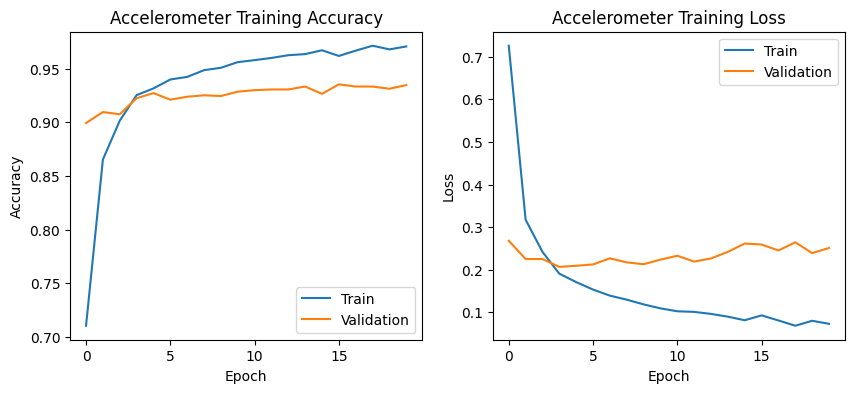

In [28]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(hist_acc.history['accuracy'])
plt.plot(hist_acc.history['val_accuracy'])
plt.title("Accelerometer Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(hist_acc.history['loss'])
plt.plot(hist_acc.history['val_loss'])
plt.title("Accelerometer Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [29]:
print("Final Training Accuracy:", hist_acc.history['accuracy'][-1])
print("Final Validation Accuracy:", hist_acc.history['val_accuracy'][-1])

Final Training Accuracy: 0.9707532525062561
Final Validation Accuracy: 0.934738278388977


# Train gyroscope model

In [30]:
start = time.time()

In [31]:
gyro_model = build_single_model(X_gyro_train.shape[1], n_classes)

hist_gyro = gyro_model.fit(
    X_gyro_train,
    y_train_enc,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

gyro_loss, gyro_acc = gyro_model.evaluate(X_gyro_test, y_test_enc)
print("Gyroscope accuracy:", gyro_acc)


Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4412 - loss: 1.3574 - val_accuracy: 0.7145 - val_loss: 0.7183
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6796 - loss: 0.7748 - val_accuracy: 0.7607 - val_loss: 0.6045
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7544 - loss: 0.6279 - val_accuracy: 0.7593 - val_loss: 0.5797
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7748 - loss: 0.5442 - val_accuracy: 0.7825 - val_loss: 0.5381
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8022 - loss: 0.5000 - val_accuracy: 0.7865 - val_loss: 0.5362
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8090 - loss: 0.4742 - val_accuracy: 0.7845 - val_loss: 0.5324
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8180 - loss: 0.4398 - val_accuracy: 0.7961 - val_loss: 0.5087
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8377 - loss: 0.4034 - val_accuracy: 0.7886 - val_loss:

In [32]:
end = time.time()
print("Training time:", end-start)

Training time: 14.301350355148315


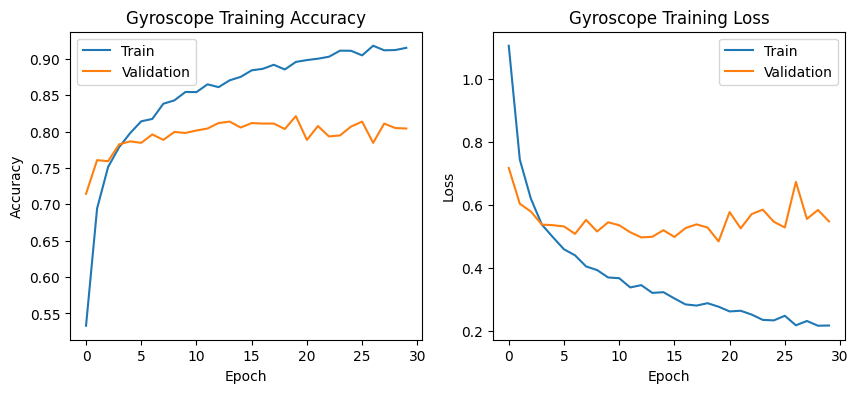

In [33]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(hist_gyro.history['accuracy'])
plt.plot(hist_gyro.history['val_accuracy'])
plt.title("Gyroscope Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(hist_gyro.history['loss'])
plt.plot(hist_gyro.history['val_loss'])
plt.title("Gyroscope Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [34]:
print("Final Training Accuracy:", hist_gyro.history['accuracy'][-1])
print("Final Validation Accuracy:", hist_gyro.history['val_accuracy'][-1])

Final Training Accuracy: 0.9151504635810852
Final Validation Accuracy: 0.8042148351669312


# Train multimodal model

Early Fusion (data-level fusion)

In [35]:
start = time.time()

In [36]:
def build_early_fusion_model(acc_dim, gyro_dim, n_classes):

    # merge sensors BEFORE the model
    input_dim = acc_dim + gyro_dim
    fusion_input = Input(shape=(input_dim,))

    x = Dense(128, activation="relu")(fusion_input)
    x = Dropout(0.3)(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)

    out = Dense(n_classes, activation="softmax")(x)

    model = Model(fusion_input, out)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [37]:
X_fusion_train = np.hstack([X_acc_train, X_gyro_train])
X_fusion_test = np.hstack([X_acc_test, X_gyro_test])

early_model = build_early_fusion_model(
    X_acc_train.shape[1],
    X_gyro_train.shape[1],
    n_classes
)

early_model.fit(
    X_fusion_train,
    y_train_enc,
    epochs=30,
    batch_size=64,
    validation_split=0.2
)

early_loss, early_acc = early_model.evaluate(X_fusion_test, y_test_enc)
print("Early Fusion Accuracy:", early_acc)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5892 - loss: 1.0096 - val_accuracy: 0.9164 - val_loss: 0.2089
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8911 - loss: 0.2822 - val_accuracy: 0.9279 - val_loss: 0.1751
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9409 - loss: 0.1708 - val_accuracy: 0.9375 - val_loss: 0.1723
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9513 - loss: 0.1323 - val_accuracy: 0.9375 - val_loss: 0.1661
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9621 - loss: 0.0989 - val_accuracy: 0.9381 - val_loss: 0.1502
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9714 - loss: 0.0864 - val_accuracy: 0.9381 - val_loss: 0.1926
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9705 - loss: 0.0885 - val_accuracy: 0.9381 - val_loss: 0.1762
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9717 - loss: 0.0714 - val_accuracy: 0.9388 - val_loss:

In [38]:
end = time.time()
print("Training time:", end-start)

Training time: 15.70227837562561


# mid fusion model

In [39]:
start = time.time()

In [40]:
def build_mid_fusion_model(acc_dim, gyro_dim, n_classes):

    # accelerometer branch
    acc_input = Input(shape=(acc_dim,))
    acc_branch = Dense(128, activation="relu")(acc_input)
    acc_branch = Dropout(0.3)(acc_branch)

    # gyroscope branch
    gyro_input = Input(shape=(gyro_dim,))
    gyro_branch = Dense(128, activation="relu")(gyro_input)
    gyro_branch = Dropout(0.3)(gyro_branch)

    # feature fusion
    fusion = Concatenate()([acc_branch, gyro_branch])

    fusion = Dense(128, activation="relu")(fusion)
    fusion = Dropout(0.4)(fusion)

    out = Dense(n_classes, activation="softmax")(fusion)

    model = Model([acc_input, gyro_input], out)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [41]:
mid_model = build_mid_fusion_model(
    X_acc_train.shape[1],
    X_gyro_train.shape[1],
    n_classes
)

mid_model.fit(
    [X_acc_train, X_gyro_train],
    y_train_enc,
    epochs=30,
    batch_size=64,
    validation_split=0.2
)

mid_loss, mid_acc = mid_model.evaluate(
    [X_acc_test, X_gyro_test],
    y_test_enc
)

print("Mid Fusion Accuracy:", mid_acc)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5978 - loss: 1.0008 - val_accuracy: 0.9239 - val_loss: 0.1895
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9040 - loss: 0.2555 - val_accuracy: 0.9456 - val_loss: 0.1252
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9388 - loss: 0.1641 - val_accuracy: 0.9381 - val_loss: 0.1462
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9538 - loss: 0.1249 - val_accuracy: 0.9320 - val_loss: 0.1456
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9617 - loss: 0.1003 - val_accuracy: 0.9483 - val_loss: 0.1268
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9754 - loss: 0.0675 - val_accuracy: 0.9463 - val_loss: 0.1258
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9768 - loss: 0.0656 - val_accuracy: 0.9463 - val_loss: 0.1324
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9699 - loss: 0.0740 - val_accuracy: 0.9470 - val_loss:

In [42]:
end = time.time()
print("Training time:", end-start)

Training time: 17.760928630828857


# late fusion model

In [43]:
start = time.time()

In [44]:
def build_late_fusion_model(acc_dim, gyro_dim, n_classes):

    # accelerometer branch
    acc_input = Input(shape=(acc_dim,))
    acc_branch = Dense(128, activation="relu")(acc_input)
    acc_branch = Dropout(0.3)(acc_branch)
    acc_out = Dense(n_classes, activation="softmax")(acc_branch)

    # gyroscope branch
    gyro_input = Input(shape=(gyro_dim,))
    gyro_branch = Dense(128, activation="relu")(gyro_input)
    gyro_branch = Dropout(0.3)(gyro_branch)
    gyro_out = Dense(n_classes, activation="softmax")(gyro_branch)

    # combine predictions
    final_out = Average()([acc_out, gyro_out])

    model = Model([acc_input, gyro_input], final_out)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [45]:
late_model = build_late_fusion_model(
    X_acc_train.shape[1],
    X_gyro_train.shape[1],
    n_classes
)

late_model.fit(
    [X_acc_train, X_gyro_train],
    y_train_enc,
    epochs=30,
    batch_size=64,
    validation_split=0.2
)

late_loss, late_acc = late_model.evaluate(
    [X_acc_test, X_gyro_test],
    y_test_enc
)

print("Late Fusion Accuracy:", late_acc)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6543 - loss: 0.9117 - val_accuracy: 0.9225 - val_loss: 0.3591
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9025 - loss: 0.3663 - val_accuracy: 0.9225 - val_loss: 0.3105
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9339 - loss: 0.2806 - val_accuracy: 0.9313 - val_loss: 0.2643
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9519 - loss: 0.2372 - val_accuracy: 0.9320 - val_loss: 0.2517
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9560 - loss: 0.2146 - val_accuracy: 0.9354 - val_loss: 0.2405
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9627 - loss: 0.1971 - val_accuracy: 0.9409 - val_loss: 0.2267
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9673 - loss: 0.1795 - val_accuracy: 0.9443 - val_loss: 0.2238
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9713 - loss: 0.1689 - val_accuracy: 0.9402 - val_loss:

In [46]:
end = time.time()
print("Training time:", end-start)

Training time: 15.471862554550171


In [47]:
results = pd.DataFrame({
    "Model": ["Early Fusion", "Mid Fusion", "Late Fusion"],
    "Accuracy": [early_acc, mid_acc, late_acc]
})
results.index = results.index + 1

print(results)

          Model  Accuracy
1  Early Fusion  0.932134
2    Mid Fusion  0.935867
3   Late Fusion  0.936206


# Compare all models

**bar chart:**

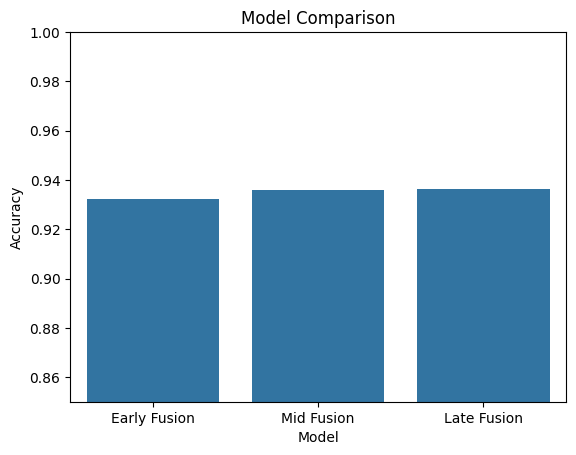

In [48]:
sns.barplot(x="Model", y="Accuracy", data=results)
plt.ylim(0.85, 1.0)
plt.title("Model Comparison")
plt.show()

# Predictions from all three models

In [49]:
# Accelerometer
y_pred_acc = acc_model.predict(X_acc_test)
y_pred_acc_labels = np.argmax(y_pred_acc, axis=1)

# Gyroscope
y_pred_gyro = gyro_model.predict(X_gyro_test)
y_pred_gyro_labels = np.argmax(y_pred_gyro, axis=1)

# Early fusion
y_pred_early = early_model.predict(X_fusion_test)
y_pred_early_labels = np.argmax(y_pred_early, axis=1)

# Mid fusion
y_pred_mid = mid_model.predict([X_acc_test, X_gyro_test])
y_pred_mid_labels = np.argmax(y_pred_mid, axis=1)

# Late fusion
y_pred_late = late_model.predict([X_acc_test, X_gyro_test])
y_pred_late_labels = np.argmax(y_pred_late, axis=1)

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [50]:
print("Early Fusion Classification Report")
print(classification_report(y_test_enc, y_pred_early_labels, target_names=le.classes_))

print("Mid Fusion Classification Report")
print(classification_report(y_test_enc, y_pred_mid_labels, target_names=le.classes_))

print("Late Fusion Classification Report")
print(classification_report(y_test_enc, y_pred_late_labels, target_names=le.classes_))

Early Fusion Classification Report
                    precision    recall  f1-score   support

            LAYING       1.00      0.95      0.98       537
           SITTING       0.94      0.86      0.90       491
          STANDING       0.85      0.95      0.90       532
           WALKING       0.90      0.99      0.94       496
WALKING_DOWNSTAIRS       0.97      0.90      0.93       420
  WALKING_UPSTAIRS       0.96      0.92      0.94       471

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947

Mid Fusion Classification Report
                    precision    recall  f1-score   support

            LAYING       1.00      0.98      0.99       537
           SITTING       0.96      0.86      0.91       491
          STANDING       0.87      0.97      0.92       532
           WALKING       0.97      0.92      0.94       496
WALKING_DOWNSTAIRS       0.9

# Function to plot confusion matrix

In [51]:
def plot_cm(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()


# Confusion matrices for all three models

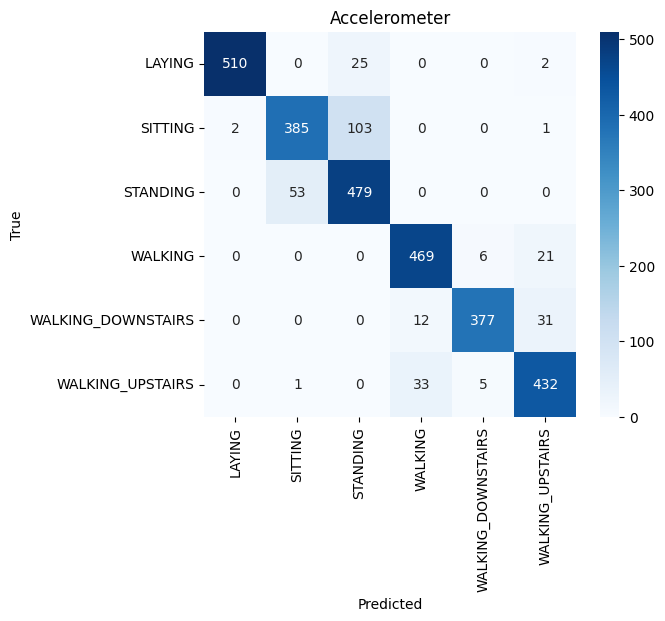

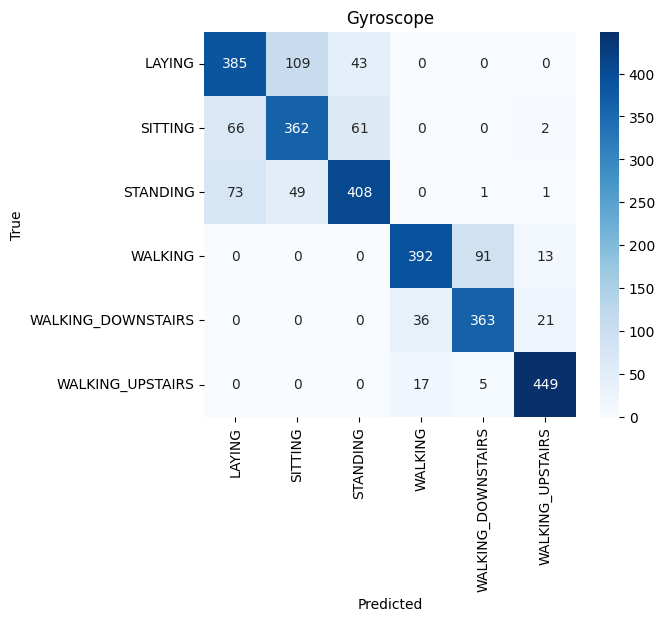

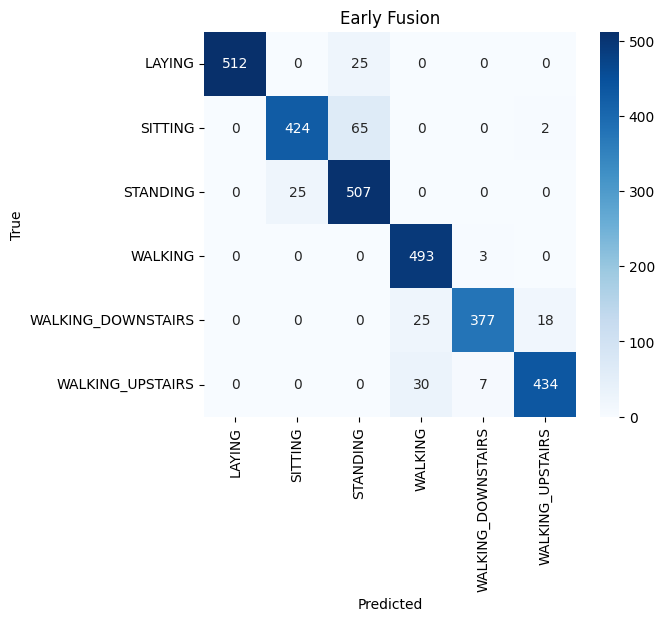

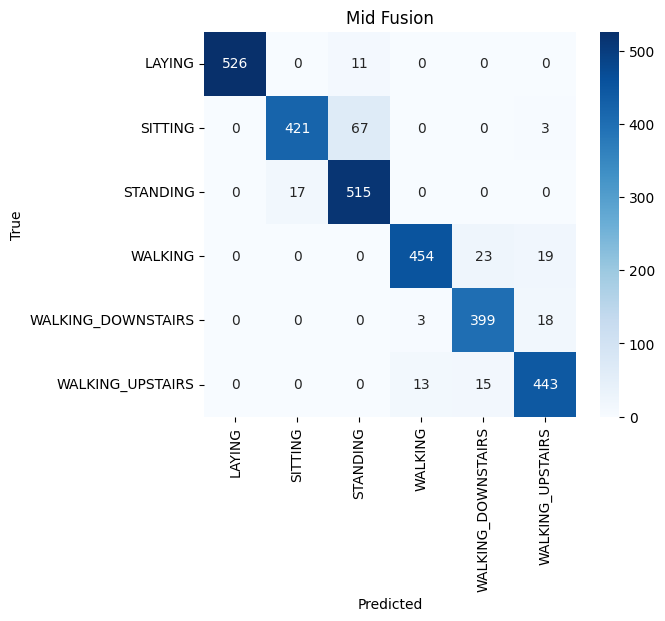

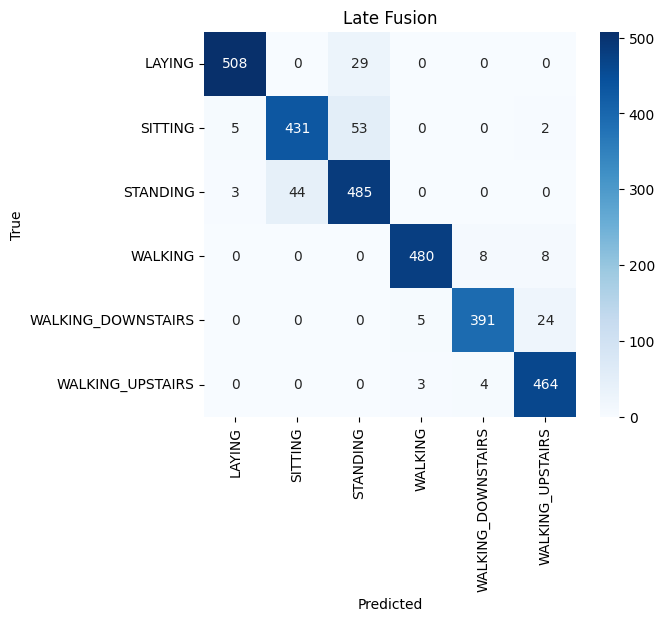

In [52]:
plot_cm(y_test_enc, y_pred_acc_labels, le.classes_, "Accelerometer")
plot_cm(y_test_enc, y_pred_gyro_labels, le.classes_, "Gyroscope")
plot_cm(y_test_enc, y_pred_early_labels, le.classes_, "Early Fusion")
plot_cm(y_test_enc, y_pred_mid_labels, le.classes_, "Mid Fusion")
plot_cm(y_test_enc, y_pred_late_labels, le.classes_, "Late Fusion")

# McNemar test function

In [53]:
def mcnemar_test(y_true, pred1, pred2, name1, name2):
    
    # contingency table
    correct1 = (pred1 == y_true)
    correct2 = (pred2 == y_true)
    
    n01 = np.sum((correct1 == 1) & (correct2 == 0))
    n10 = np.sum((correct1 == 0) & (correct2 == 1))
    
    table = [[0, n01],
             [n10, 0]]
    
    result = mcnemar(table, exact=True)
    
    print(f"{name1} vs {name2}")
    print("n01:", n01, " n10:", n10)
    print("p-value:", result.pvalue)
    
    if result.pvalue < 0.05:
        print("Difference is statistically significant\n")
    else:
        print("No significant difference\n")


In [54]:
# Accelerometer vs Gyroscope
mcnemar_test(
    y_test_enc,
    y_pred_acc_labels,
    y_pred_gyro_labels,
    "Accelerometer",
    "Gyroscope"
)

Accelerometer vs Gyroscope
n01: 498  n10: 205
p-value: 5.067719945057394e-29
Difference is statistically significant



In [55]:
# Accelerometer vs Early Fusion
mcnemar_test(
    y_test_enc,
    y_pred_acc_labels,
    y_pred_early_labels,
    "Accelerometer",
    "Early Fusion"
)

Accelerometer vs Early Fusion
n01: 54  n10: 149
p-value: 1.783643501238396e-11
Difference is statistically significant



In [56]:
# Accelerometer vs Mid Fusion
mcnemar_test(
    y_test_enc,
    y_pred_acc_labels,
    y_pred_mid_labels,
    "Accelerometer",
    "Mid Fusion"
)

Accelerometer vs Mid Fusion
n01: 61  n10: 167
p-value: 1.3954128007908521e-12
Difference is statistically significant



In [57]:
# Accelerometer vs Late Fusion
mcnemar_test(
    y_test_enc,
    y_pred_acc_labels,
    y_pred_late_labels,
    "Accelerometer",
    "Late Fusion"
)

Accelerometer vs Late Fusion
n01: 44  n10: 151
p-value: 6.305660624938112e-15
Difference is statistically significant



In [58]:
mcnemar_test(y_test_enc, y_pred_early_labels, y_pred_mid_labels,
             "Early Fusion", "Mid Fusion")

mcnemar_test(y_test_enc, y_pred_early_labels, y_pred_late_labels,
             "Early Fusion", "Late Fusion")

mcnemar_test(y_test_enc, y_pred_mid_labels, y_pred_late_labels,
             "Mid Fusion", "Late Fusion")

Early Fusion vs Mid Fusion
n01: 69  n10: 80
p-value: 0.4127425588241422
No significant difference

Early Fusion vs Late Fusion
n01: 65  n10: 77
p-value: 0.35599982591510815
No significant difference

Mid Fusion vs Late Fusion
n01: 79  n10: 80
p-value: 0.9999999999999993
No significant difference



# Gradient Boosting

# Accelerometer model (XGBoost)

In [59]:
start = time.time()

In [60]:
xgb_acc = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

xgb_acc.fit(X_acc_train, y_train_enc)

y_pred_acc = xgb_acc.predict(X_acc_test)
acc_acc = accuracy_score(y_test_enc, y_pred_acc)

print("XGB Accelerometer accuracy:", acc_acc)


XGB Accelerometer accuracy: 0.8975229046487954


In [61]:
end = time.time()
print("Training time:", end-start)

Training time: 42.30289912223816


# Gyroscope model (XGBoost)


In [62]:
start = time.time()

In [63]:
xgb_gyro = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

xgb_gyro.fit(X_gyro_train, y_train_enc)

y_pred_gyro = xgb_gyro.predict(X_gyro_test)
gyro_acc = accuracy_score(y_test_enc, y_pred_gyro)

print("XGB Gyroscope accuracy:", gyro_acc)


XGB Gyroscope accuracy: 0.8554462164913471


In [64]:
end = time.time()
print("Training time:", end-start)

Training time: 41.19910407066345


# Multimodal fusion (XGBoost)

In [65]:
start = time.time()

In [66]:
X_fusion_train = np.hstack([X_acc_train, X_gyro_train])
X_fusion_test  = np.hstack([X_acc_test, X_gyro_test])

xgb_fusion = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

xgb_fusion.fit(X_fusion_train, y_train_enc)

y_pred_fusion = xgb_fusion.predict(X_fusion_test)
fusion_acc = accuracy_score(y_test_enc, y_pred_fusion)

print("XGB Fusion accuracy:", fusion_acc)


XGB Fusion accuracy: 0.9379029521547336


In [67]:
end = time.time()
print("Training time:", end-start)

Training time: 81.57386040687561


<Figure size 1000x600 with 0 Axes>

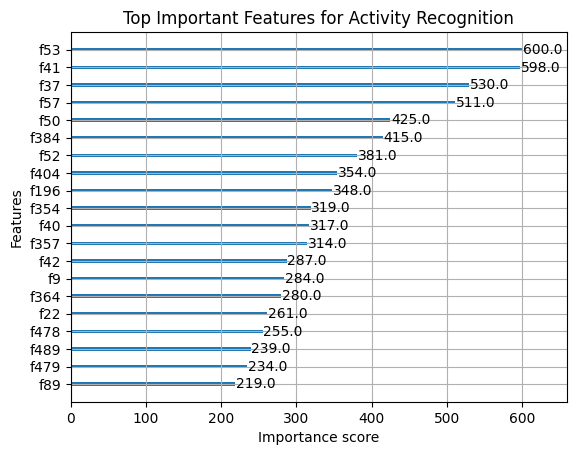

In [68]:
plt.figure(figsize=(10,6))
plot_importance(xgb_fusion, max_num_features=20)
plt.title("Top Important Features for Activity Recognition")
plt.show()

In [69]:
y_pred_xgb = xgb_fusion.predict(X_fusion_test)


# SVM

# SVM: accelerometer

In [70]:
start = time.time()

In [71]:
svm_acc = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

svm_acc.fit(X_acc_train, y_train_enc)

y_pred_acc = svm_acc.predict(X_acc_test)
acc_acc = accuracy_score(y_test_enc, y_pred_acc)

print("SVM Accelerometer:", acc_acc)


SVM Accelerometer: 0.9134713267729895


In [72]:
end = time.time()
print("Training time:", end-start)

Training time: 3.855634927749634


# SVM: gyroscope

In [73]:
start = time.time()

In [74]:
svm_gyro = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

svm_gyro.fit(X_gyro_train, y_train_enc)

y_pred_gyro = svm_gyro.predict(X_gyro_test)
gyro_acc = accuracy_score(y_test_enc, y_pred_gyro)

print("SVM Gyroscope:", gyro_acc)


SVM Gyroscope: 0.8028503562945368


In [75]:
end = time.time()
print("Training time:", end-start)

Training time: 4.7509238719940186


# SVM: multimodal fusion

In [76]:
start = time.time()

In [77]:
X_fusion_train = np.hstack([X_acc_train, X_gyro_train])
X_fusion_test  = np.hstack([X_acc_test, X_gyro_test])

svm_fusion = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

svm_fusion.fit(X_fusion_train, y_train_enc)

y_pred_fusion = svm_fusion.predict(X_fusion_test)
fusion_acc = accuracy_score(y_test_enc, y_pred_fusion)

print("SVM Fusion:", fusion_acc)


SVM Fusion: 0.9538513742789277


In [78]:
end = time.time()
print("Training time:", end-start)

Training time: 5.743326902389526


In [79]:
y_pred_svm = svm_fusion.predict(X_fusion_test)


In [80]:
errors = y_pred_svm != y_test_enc

misclassified = pd.DataFrame({
    "True Label": le.inverse_transform(y_test_enc[errors]),
    "Predicted": le.inverse_transform(y_pred_svm[errors])
})

print("Most common mistakes:")
print(
    misclassified.value_counts().head(10)
)

Most common mistakes:
True Label          Predicted         
SITTING             STANDING              48
WALKING_DOWNSTAIRS  WALKING_UPSTAIRS      27
STANDING            SITTING               17
WALKING_UPSTAIRS    WALKING               16
WALKING_DOWNSTAIRS  WALKING                8
WALKING             WALKING_DOWNSTAIRS     8
                    WALKING_UPSTAIRS       5
SITTING             LAYING                 4
WALKING_UPSTAIRS    WALKING_DOWNSTAIRS     2
SITTING             WALKING_UPSTAIRS       1
Name: count, dtype: int64


In [81]:
param_grid = {
    "C": [1, 5, 10, 20],
    "gamma": ["scale", 0.01, 0.005]
}

grid = GridSearchCV(
    SVC(kernel="rbf"),
    param_grid,
    cv=3,
    n_jobs=-1
)

grid.fit(X_fusion_train, y_train_enc)

print("Best params:", grid.best_params_)
print("CV accuracy:", grid.best_score_)

svm_fusion = grid.best_estimator_
fusion_acc = accuracy_score(y_test_enc,
                            svm_fusion.predict(X_fusion_test))

print("Tuned SVM Fusion:", fusion_acc)


Best params: {'C': 5, 'gamma': 'scale'}
CV accuracy: 0.9326731557576111
Tuned SVM Fusion: 0.9535120461486257


# COMAPARISON

**F1 Scores, Recall, Precision, Accuracy**

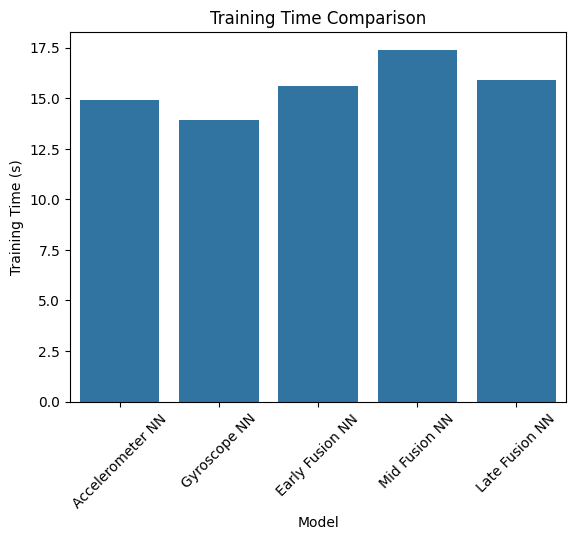

In [82]:
time_results = pd.DataFrame({
"Model": ["Accelerometer NN","Gyroscope NN","Early Fusion NN","Mid Fusion NN","Late Fusion NN"],
"Training Time (s)": [14.9,13.9,15.6,17.4,15.9]
})

sns.barplot(x="Model", y="Training Time (s)", data=time_results)
plt.xticks(rotation=45)
plt.title("Training Time Comparison")
plt.show()

In [83]:
sensor_comparison = pd.DataFrame({
    "Sensor Setup":[
        "Accelerometer Only",
        "Gyroscope Only",
        "Multimodal Fusion"
    ],
    "Accuracy":[
        acc_acc,
        gyro_acc,
        fusion_acc
    ]
})

print(sensor_comparison)

         Sensor Setup  Accuracy
0  Accelerometer Only  0.913471
1      Gyroscope Only  0.802850
2   Multimodal Fusion  0.953512


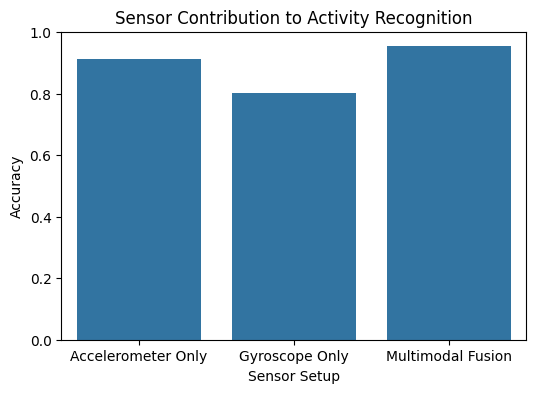

In [84]:
plt.figure(figsize=(6,4))
sns.barplot(
    x="Sensor Setup",
    y="Accuracy",
    data=sensor_comparison
)
plt.title("Sensor Contribution to Activity Recognition")
plt.show()

In [85]:
summary = pd.DataFrame({
"Model": ["MLP Early Fusion","MLP Mid Fusion","MLP Late Fusion",
          "XGB Fusion","SVM Fusion"],
"Accuracy": [
accuracy_score(y_test_enc, y_pred_early_labels),
accuracy_score(y_test_enc, y_pred_mid_labels),
accuracy_score(y_test_enc, y_pred_late_labels),
accuracy_score(y_test_enc, y_pred_xgb),
accuracy_score(y_test_enc, y_pred_svm)
],
"Precision":[
precision_score(y_test_enc, y_pred_early_labels, average="weighted"),
precision_score(y_test_enc, y_pred_mid_labels, average="weighted"),
precision_score(y_test_enc, y_pred_late_labels, average="weighted"),
precision_score(y_test_enc, y_pred_xgb, average="weighted"),
precision_score(y_test_enc, y_pred_svm, average="weighted")
],
"Recall":[
recall_score(y_test_enc, y_pred_early_labels, average="weighted"),
recall_score(y_test_enc, y_pred_mid_labels, average="weighted"),
recall_score(y_test_enc, y_pred_late_labels, average="weighted"),
recall_score(y_test_enc, y_pred_xgb, average="weighted"),
recall_score(y_test_enc, y_pred_svm, average="weighted")
],
"F1":[
f1_score(y_test_enc, y_pred_early_labels, average="weighted"),
f1_score(y_test_enc, y_pred_mid_labels, average="weighted"),
f1_score(y_test_enc, y_pred_late_labels, average="weighted"),
f1_score(y_test_enc, y_pred_xgb, average="weighted"),
f1_score(y_test_enc, y_pred_svm, average="weighted")
]
})

print(summary.sort_values("Accuracy", ascending=False))

              Model  Accuracy  Precision    Recall        F1
4        SVM Fusion  0.953851   0.954609  0.953851  0.953684
3        XGB Fusion  0.937903   0.939205  0.937903  0.937686
2   MLP Late Fusion  0.936206   0.937720  0.936206  0.936503
1    MLP Mid Fusion  0.935867   0.938430  0.935867  0.935958
0  MLP Early Fusion  0.932134   0.935893  0.932134  0.932404


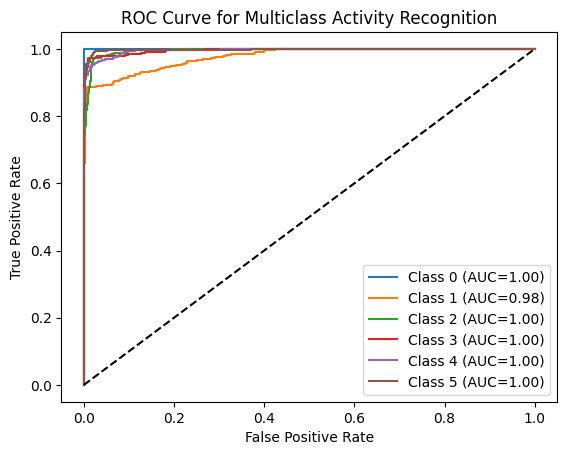

In [86]:
y_test_bin = label_binarize(y_test_enc, classes=range(n_classes))

y_score = svm_fusion.decision_function(X_fusion_test)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC={roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Multiclass Activity Recognition")
plt.legend()
plt.show()

# Results

In [87]:
results = pd.DataFrame({
"Model": [
"XGB Accelerometer",
"XGB Gyroscope",
"XGB Fusion",
"SVM Accelerometer",
"SVM Gyroscope",
"SVM Fusion",
"MLP Fusion"
],
"Accuracy": [
accuracy_score(y_test_enc, xgb_acc.predict(X_acc_test)),
accuracy_score(y_test_enc, xgb_gyro.predict(X_gyro_test)),
accuracy_score(y_test_enc, xgb_fusion.predict(X_fusion_test)),
accuracy_score(y_test_enc, svm_acc.predict(X_acc_test)),
accuracy_score(y_test_enc, svm_gyro.predict(X_gyro_test)),
accuracy_score(y_test_enc, svm_fusion.predict(X_fusion_test)),
accuracy_score(y_test_enc, np.argmax(mid_model.predict([X_acc_test, X_gyro_test]), axis=1))
]
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)

print(results)

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
               Model  Accuracy
0         SVM Fusion  0.953512
1         XGB Fusion  0.937903
2         MLP Fusion  0.935867
3  SVM Accelerometer  0.913471
4  XGB Accelerometer  0.897523
5      XGB Gyroscope  0.855446
6      SVM Gyroscope  0.802850


In [88]:
best_model = results.iloc[0]

print("Best Model:", best_model["Model"])
print("Accuracy:", best_model["Accuracy"])


Best Model: SVM Fusion
Accuracy: 0.9535120461486257


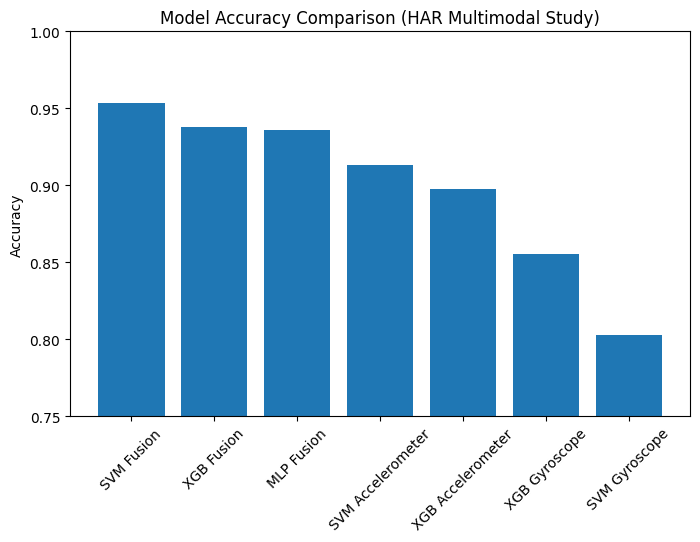

In [89]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Accuracy"])
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison (HAR Multimodal Study)")
plt.ylim(0.75, 1.0)
plt.show()


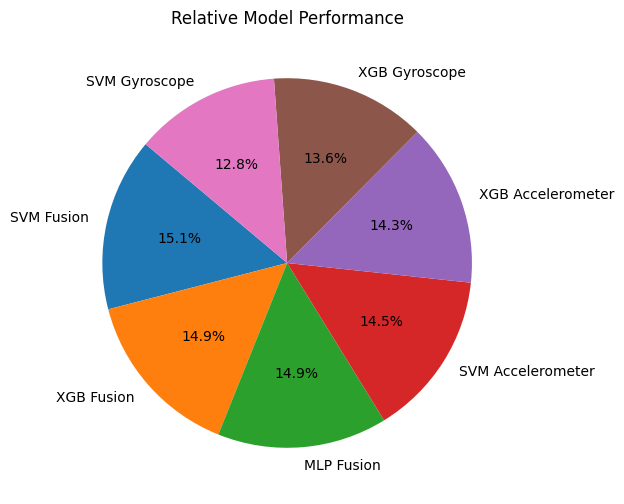

In [90]:
plt.figure(figsize=(6,6))
plt.pie(
    results["Accuracy"],
    labels=results["Model"],
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Relative Model Performance")
plt.show()


In [91]:
rows = []

# XGBoost Fusion
if "xgb_fusion" in globals():
    rows.append([
        "XGB Fusion",
        accuracy_score(y_test_enc, xgb_fusion.predict(X_fusion_test))
    ])

# SVM Fusion
if "svm_fusion" in globals():
    rows.append([
        "SVM Fusion",
        accuracy_score(y_test_enc, svm_fusion.predict(X_fusion_test))
    ])

# MLP Early Fusion
if "early_model" in globals():
    rows.append([
        "MLP Early Fusion",
        accuracy_score(
            y_test_enc,
            np.argmax(early_model.predict(X_fusion_test), axis=1)
        )
    ])

# MLP Mid Fusion
if "mid_model" in globals():
    rows.append([
        "MLP Mid Fusion",
        accuracy_score(
            y_test_enc,
            np.argmax(mid_model.predict([X_acc_test, X_gyro_test]), axis=1)
        )
    ])

# MLP Late Fusion
if "late_model" in globals():
    rows.append([
        "MLP Late Fusion",
        accuracy_score(
            y_test_enc,
            np.argmax(late_model.predict([X_acc_test, X_gyro_test]), axis=1)
        )
    ])

multi_results = (
    pd.DataFrame(rows, columns=["Model", "Accuracy"])
      .sort_values("Accuracy", ascending=False)
      .reset_index(drop=True)
)

multi_results

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Model,Accuracy
0,SVM Fusion,0.953512
1,XGB Fusion,0.937903
2,MLP Late Fusion,0.936206
3,MLP Mid Fusion,0.935867
4,MLP Early Fusion,0.932134


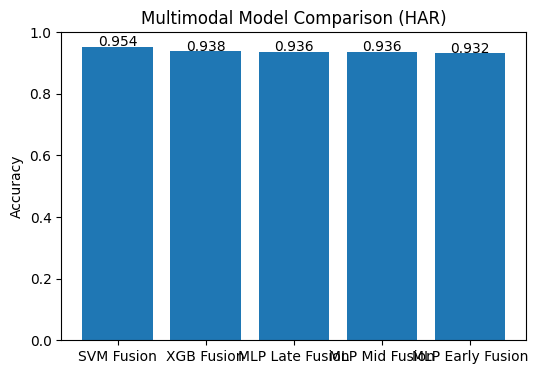

In [92]:
plt.figure(figsize=(6,4))
plt.bar(multi_results["Model"], multi_results["Accuracy"])

plt.ylabel("Accuracy")
plt.title("Multimodal Model Comparison (HAR)")
plt.ylim(0,1)

for i, v in enumerate(multi_results["Accuracy"]):
    plt.text(i, v + 0.002, f"{v:.3f}", ha="center")

plt.show()
